In [1]:
import sys
import os
if os.path.abspath('..') not in sys.path:
    sys.path.append(os.path.abspath('..'))

from matplotlib import pyplot as plt
import conquer3d as c3d

import torch
import tqdm
import numpy as np
import kaolin as kal
import render
import open3d as o3d
import util
import nvdiffrast.torch as dr


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
iter = 1000
batch = 8
train_res = [2048, 2048]
learning_rate = 0.01
voxel_grid_res = 64
device = 'cuda'

glctx = dr.RasterizeCudaContext(device=device)


In [3]:
mesh = o3d.io.read_triangle_mesh(o3d.data.BunnyMesh().path)

print("# vertices:", len(mesh.vertices))
print("# triangles:", len(mesh.triangles))

# Make front face towards +Z
R = mesh.get_rotation_matrix_from_xyz((0, np.pi, 0))
mesh.rotate(R, center=(0, 0, 0))

vertices = np.asarray(mesh.vertices).astype(np.float32)
triangles = np.asarray(mesh.triangles).astype(np.int64)

vertices = torch.from_numpy(vertices).float()
triangles = torch.from_numpy(triangles).long()

vmin, vmax = vertices.min(dim=0)[0], vertices.max(dim=0)[0]
scale = 1.8 / torch.max(vmax - vmin).item()

vertices = vertices - (vmax + vmin) / 2
vertices = vertices * scale

vertices = vertices.to(device)
triangles = triangles.to(device)

# Generate rainbow colors for the ground truth mesh based on normalized coordinates
gt_colors = (vertices - vertices.min(dim=0)[0]) / (vertices.max(dim=0)[0] - vertices.min(dim=0)[0])

gt_mesh = kal.rep.SurfaceMesh(vertices=vertices, faces=triangles)
gt_mesh.vertex_colors = gt_colors


# vertices: 35947
# triangles: 69451


In [4]:
num_sampling_points = 100000

pc, _ = kal.ops.mesh.sample_points(gt_mesh.vertices.unsqueeze(0), gt_mesh.faces, num_sampling_points)
pc = pc.squeeze(0)

grid_min = pc.min(dim=0)[0].tolist()
grid_max = pc.max(dim=0)[0].tolist()

padding = 0.1
grid_min = [x - padding for x in grid_min]
grid_max = [x + padding for x in grid_max]

grid_vertices, voxels, _ = c3d.data_structure.create_voxel_grid(
    grid_min=grid_min,
    grid_max=grid_max,
    res=[voxel_grid_res, voxel_grid_res, voxel_grid_res],
    device=device
)

sdf = torch.rand_like(grid_vertices[:,0]) - 0.1
sdf = torch.nn.Parameter(sdf.clone().detach(), requires_grad=True)

grid_colors = torch.ones_like(grid_vertices) * 0.5
grid_colors = torch.nn.Parameter(grid_colors.clone().detach(), requires_grad=True)

print(f"sdf requires_grad: {sdf.requires_grad}")
print(f"grid_colors requires_grad: {grid_colors.requires_grad}")


sdf requires_grad: True
grid_colors requires_grad: True


vertices: torch.Size([139896, 3]), faces: torch.Size([200444, 3])


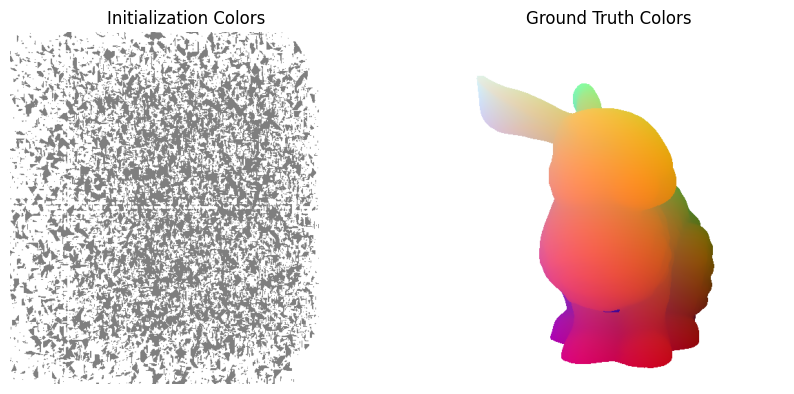

In [5]:
with torch.no_grad():
    mc_vertices, mc_faces, _, mc_colors = c3d.ops.diff_marching_cubes(
        grid_vertices, voxels, sdf, grid_colors=grid_colors, iso=0.0)

print(f"vertices: {mc_vertices.shape}, faces: {mc_faces.shape}")
if mc_vertices.shape[0] > 0:
    init_mesh = kal.rep.SurfaceMesh(vertices=mc_vertices, faces=mc_faces)
    init_mesh.vertex_colors = mc_colors
    
    camera = render.get_rotate_camera(5)
    f, ax = plt.subplots(1, 2, figsize=(10, 5))
    output = render.render_mesh(glctx, init_mesh, camera, [512, 512], return_types=['colors'], white_bg=True)
    ax[0].imshow(output['colors'][0].cpu().detach().numpy())
    ax[0].set_title("Initialization Colors")
    ax[0].axis('off')
    
    output = render.render_mesh(glctx, gt_mesh, camera, [512, 512], return_types=['colors'], white_bg=True)
    ax[1].imshow(output['colors'][0].cpu().detach().numpy())
    ax[1].set_title("Ground Truth Colors")
    ax[1].axis('off')
    plt.show()


In [6]:
def lr_schedule(iter):
    return max(0.0, 10 ** (-(iter) * 0.0002))

optimizer = torch.optim.Adam([sdf, grid_colors], lr=learning_rate)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda x: lr_schedule(x))


In [7]:
for it in tqdm.tqdm(range(iter)): 
    optimizer.zero_grad()
    # sample random camera poses
    cameras = render.get_random_camera_batch(batch, iter_res=train_res, device=device)
    
    # render gt mesh at sampled views
    target = render.render_mesh(glctx, gt_mesh, cameras, train_res, return_types = ["mask", "depth", "colors"])

    # mesh extraction
    mc_vertices, mc_faces, _, mc_colors = c3d.ops.diff_marching_cubes(
        grid_vertices=grid_vertices, 
        voxels=voxels, 
        voxel_values=sdf,
        grid_colors=grid_colors,
        iso=0.0
    )
    
    if mc_vertices.shape[0] == 0:
        continue
    
    extracted_mesh = kal.rep.SurfaceMesh(vertices=mc_vertices, faces=mc_faces.int())
    extracted_mesh.vertex_colors = mc_colors
    
    buffers = render.render_mesh(glctx, extracted_mesh, cameras, train_res, return_types = ["mask", "depth", "colors"])

    # reconstruction loss
    mask_loss = (buffers['mask'] - target['mask']).abs().mean() # mask loss
    depth_loss = (((((buffers['depth'] - target['depth']) * target['mask'])**2).sum(-1)+1e-8)).sqrt().mean() * 10
    
    # color loss: L1 masked
    color_loss = ((buffers['colors'] - target['colors']).abs() * target['mask']).mean() * 10

    total_loss = mask_loss + depth_loss + color_loss
    total_loss.backward()
    optimizer.step()
    scheduler.step()
    
    if (it + 1) % 100 == 0:
        print(f"Iter {it+1}/{iter}, Mask: {mask_loss.item():.4f}, Depth: {depth_loss.item():.4f}, Color: {color_loss.item():.4f}, Total: {total_loss.item():.4f}")


 10%|█         | 105/1000 [00:04<00:41, 21.78it/s]

Iter 100/1000, Mask: 0.0040, Depth: 0.1359, Color: 0.0444, Total: 0.1843


 20%|██        | 204/1000 [00:09<00:36, 22.04it/s]

Iter 200/1000, Mask: 0.0009, Depth: 0.0310, Color: 0.0115, Total: 0.0435


 30%|███       | 303/1000 [00:13<00:31, 22.45it/s]

...

Iter 800/1000, Mask: 0.0010, Depth: 0.0790, Color: 0.0170, Total: 0.0970


 90%|█████████ | 903/1000 [00:41<00:04, 22.59it/s]

Iter 900/1000, Mask: 0.0009, Depth: 0.0512, Color: 0.0127, Total: 0.0648


100%|██████████| 1000/1000 [00:45<00:00, 21.99it/s]

Iter 1000/1000, Mask: 0.0009, Depth: 0.0383, Color: 0.0091, Total: 0.0483


In [8]:
with torch.no_grad():
    mc_vertices, mc_faces, _, mc_colors = c3d.ops.diff_marching_cubes(
        grid_vertices=grid_vertices,
        voxels=voxels, 
        voxel_values=sdf,
        grid_colors=grid_colors,
        iso=0.0
    )
    
final_mesh = kal.rep.SurfaceMesh(vertices=mc_vertices, faces=mc_faces)
final_mesh.vertex_colors = mc_colors
print(f"Final vertices: {mc_vertices.shape}, Final faces: {mc_faces.shape}")


Final vertices: torch.Size([52894, 3]), Final faces: torch.Size([107708, 3])


In [9]:
# Evaluate using c3d chamfer distance
pc_prime, _ = kal.ops.mesh.sample_points(final_mesh.vertices.unsqueeze(0), final_mesh.faces, num_sampling_points)
pc_prime = pc_prime.squeeze(0)

chamfer_dist = c3d.ops.chamfer_distance(pc, pc_prime, squared=True)
print(f"Chamfer Distance: {chamfer_dist.item():.6f}")


Chamfer Distance: 0.020843


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0059171505..1.0].


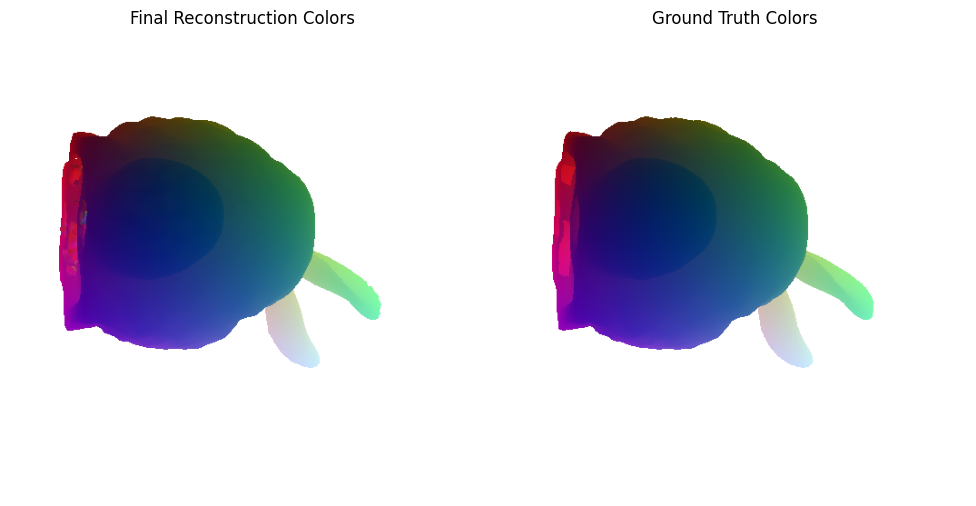

In [10]:
# Rotate final mesh around the X-axis by 90 degrees to make Z-upward axis
angle = torch.tensor(np.pi / 2, device=device)
R_x = torch.tensor([
    [1.0, 0.0, 0.0],
    [0.0, torch.cos(angle), -torch.sin(angle)],
    [0.0, torch.sin(angle), torch.cos(angle)]
], device=device)

final_mesh.vertices = torch.matmul(final_mesh.vertices, R_x.T)
gt_mesh.vertices = torch.matmul(gt_mesh.vertices, R_x.T)

# Render the final oriented mesh colors using matplotlib
camera = render.get_rotate_camera(0)
output_final = render.render_mesh(glctx, final_mesh, camera, [512, 512], return_types=['colors'], white_bg=True)
img_final = output_final['colors'][0].cpu().detach().numpy()

output_gt = render.render_mesh(glctx, gt_mesh, camera, [512, 512], return_types=['colors'], white_bg=True)
img_gt = output_gt['colors'][0].cpu().detach().numpy()

f, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_final)
ax[0].set_title("Final Reconstruction Colors")
ax[0].axis('off')

ax[1].imshow(img_gt)
ax[1].set_title("Ground Truth Colors")
ax[1].axis('off')

plt.tight_layout()
plt.show()
